In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


if 'Customer_ID' in df.columns:
    df = df.drop('Customer_ID', axis=1)


bool_cols = ['Email_Opt_In', 'Target_Churn']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)


cols_to_encode = ['Gender', 'Promotion_Response']
existing_cols = [col for col in cols_to_encode if col in df.columns]

if existing_cols:
    df = pd.get_dummies(df, columns=existing_cols, drop_first=True)
    print("Columns encoded successfully!")
else:
    print("Columns already encoded or not found.")


X = df.drop('Target_Churn', axis=1)
y = df['Target_Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Columns already encoded or not found.

Final Accuracy: 52.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.39      0.44        94
           1       0.54      0.63      0.58       106

    accuracy                           0.52       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.52      0.52      0.51       200



In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

print("Tuning shuru ho rahi hai, isme 10-20 seconds lag sakte hain...")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print(f"\nTuned Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print(f"Best Parameters: {grid_search.best_params_}")


importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nTop 5 Important Features:")
print(feature_importance_df.head())

Tuning shuru ho rahi hai, isme 10-20 seconds lag sakte hain...

Tuned Accuracy: 53.00%
Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}

Top 5 Important Features:
                      Feature  Importance
5  Average_Transaction_Amount    0.127265
1               Annual_Income    0.120788
2                 Total_Spend    0.116925
9      Last_Purchase_Days_Ago    0.116437
4            Num_of_Purchases    0.109936


<Figure size 800x600 with 0 Axes>

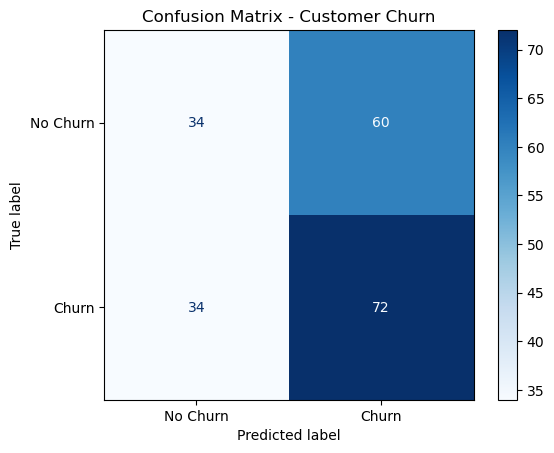

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])

X
plt.figure(figsize=(8,6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Customer Churn')
plt.show()